# S2 + TCO-OH kinetic curves

The CSV already contains the calculated `ln(A0/A)` values. The three replicate columns are plotted directly without transformation, correction, or fitting.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']='Arial'
DATA_FILE = Path("kinetics_extracted_wide.csv")

RUN_COLUMNS = {
    "Run 1": "A",
    "Run 2": "B",
    "Run 3": "C",
}

df = pd.read_csv(DATA_FILE)
df.head()


,t,A,B,C
0,0,0.00000,0.00000,0.00000
1,1,0.02894,0.02666,0.02524
2,2,0.05725,0.05302,0.05045
3,3,0.08539,0.07959,0.07566
4,4,0.11317,0.10582,0.10079


## 1. `ln(A0/A)` versus time


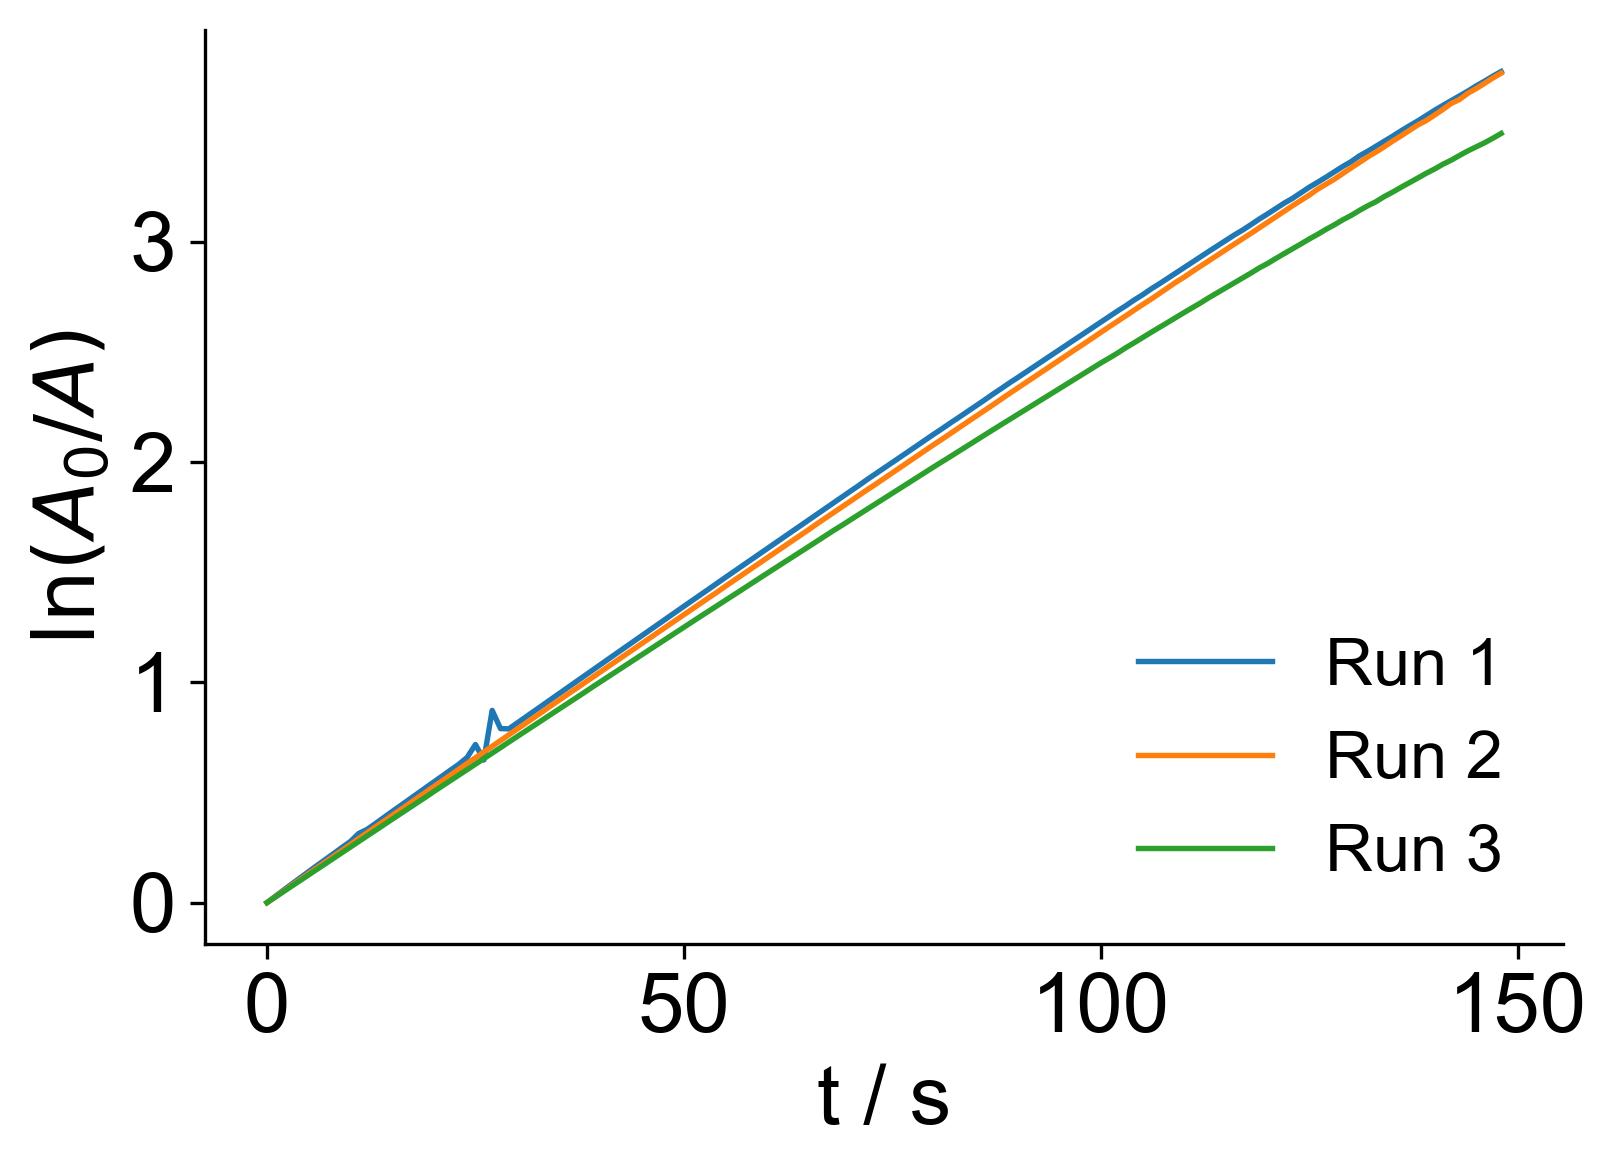

In [2]:
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

for run, col in RUN_COLUMNS.items():
    ax.plot(df["t"], df[col], linewidth=1.3, label=run)

ax.set_xlabel(r"t / s", fontsize=20)
ax.set_ylabel(r"$\ln(A_0/A)$", fontsize=20)
ax.tick_params(direction="out", labelsize=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=16, loc="lower right")
fig.tight_layout()

fig.savefig("S2_TCO_ln_A0_over_A_curves.png", dpi=600, bbox_inches="tight")
fig.savefig("S2_TCO_ln_A0_over_A_curves.pdf", bbox_inches="tight")
plt.show()


## 2. Stability of S2 in complete cell culture medium

The stability of the compound was evaluated in **DMEM (FluoroBrite) + 10% FBS at 37 °C**.  
The compound was used at a final concentration of **250 μM** with **2.5% (v/v) DMSO**.  
Aliquots were analyzed by HPLC at 0, 3, 6, 9, 12, and 24 h.

The intact fraction was calculated from the HPLC peak area at a retention time of **5.974 min**, normalized to the value at 0 h.

The SI reports the following intact fractions:

| Time (h) | Peak area | Intact fraction (%) |
|---:|---:|---:|
| 0 | 3,487,947 | 100 |
| 3 | 3,331,393 | 96 |
| 6 | 3,199,216 | 92 |
| 9 | 3,176,366 | 91 |
| 12 | 3,072,705 | 88 |
| 24 | 2,843,579 | 82 |

The bar chart below visualizes the percentage of intact compound remaining during the 24 h incubation.


In [3]:
# Stability data from the HPLC SI
stability = pd.DataFrame({
    "Time_h": [0, 3, 6, 9, 12, 24],
    "Peak_area": [3487947, 3331393, 3199216, 3176366, 3072705, 2843579],
    "Intact_fraction_percent": [100, 96, 92, 91, 88, 82],
})

stability


,Time_h,Peak_area,Intact_fraction_percent
0,0,3487947,100
1,3,3331393,96
2,6,3199216,92
3,9,3176366,91
4,12,3072705,88
5,24,2843579,82


C:\Users\Jackie\AppData\Local\Temp\ipykernel_51788\2116933719.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.16, 1, 1])


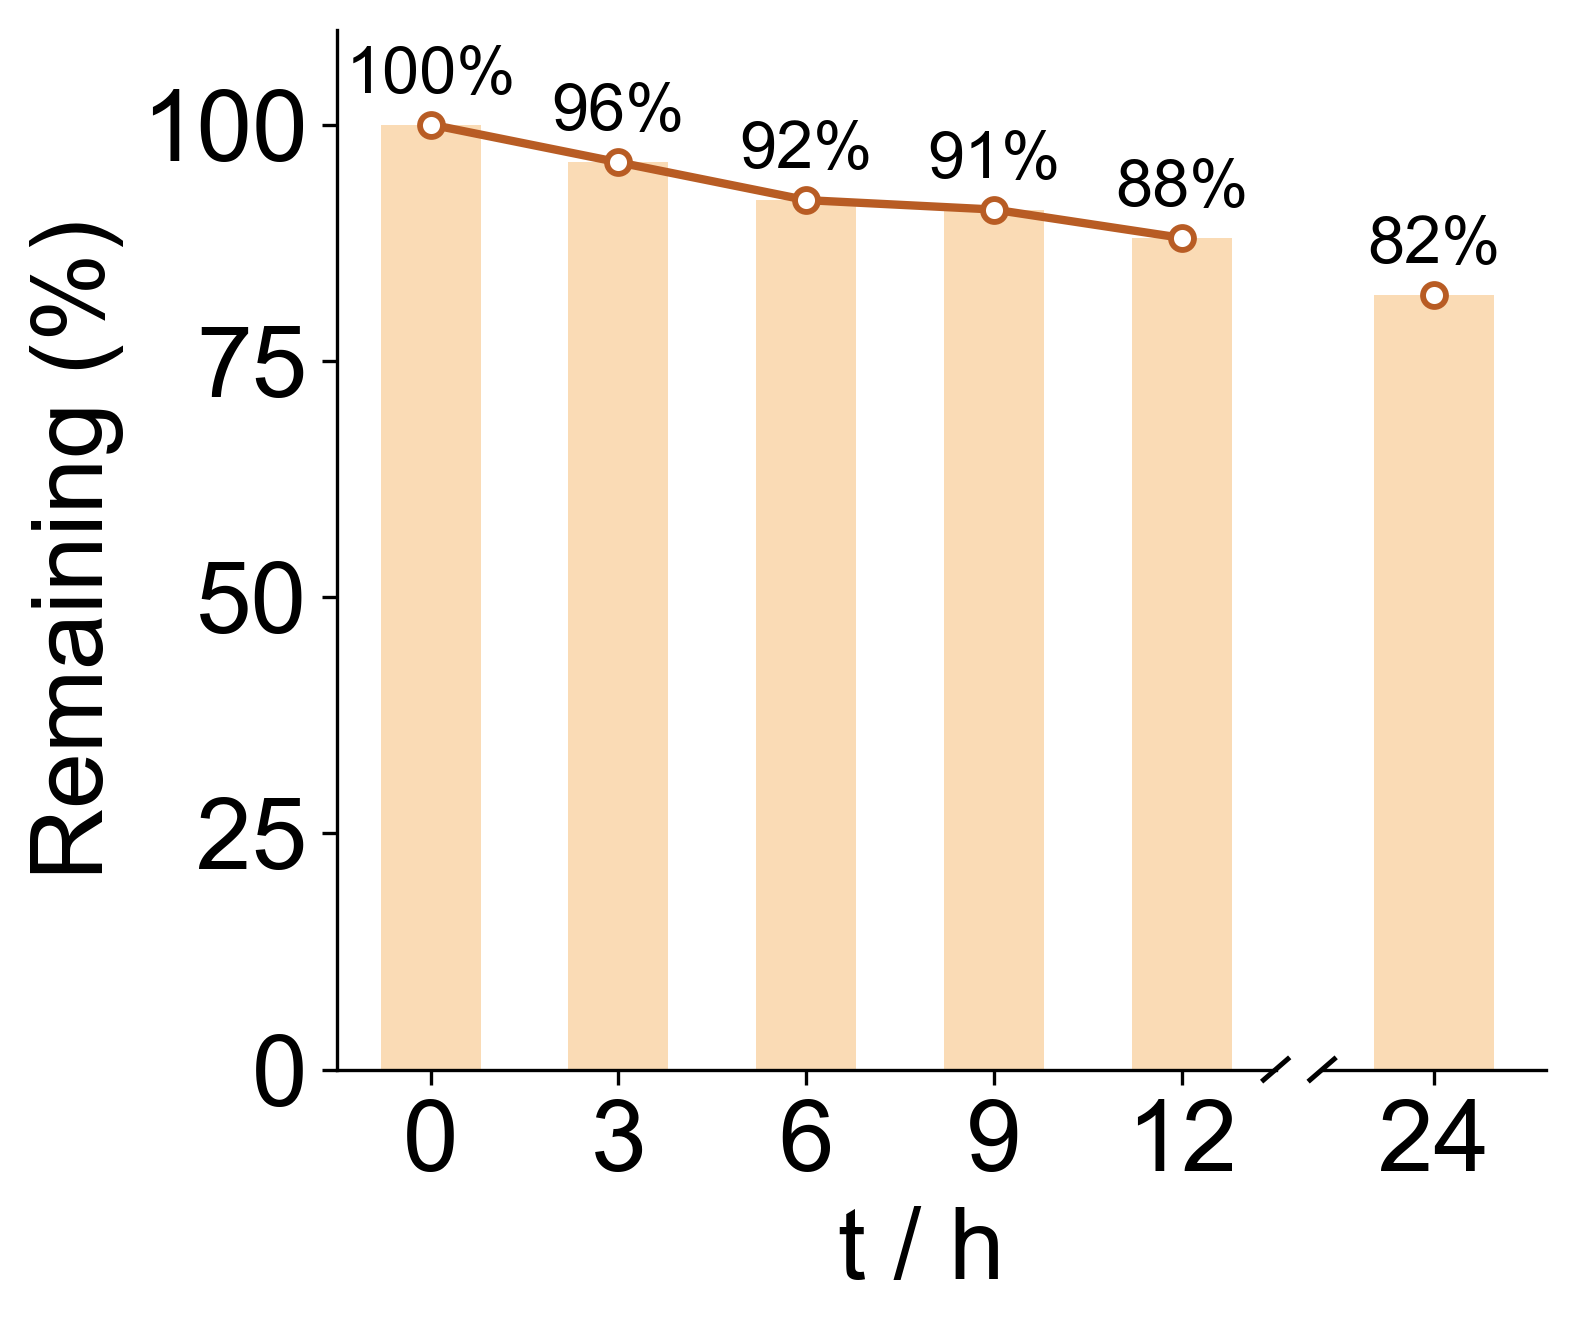

In [4]:
# Publication-style stability bar + line chart with a broken x-axis
from matplotlib.lines import Line2D
fig, (ax, ax24) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(5.2, 4.5),
    dpi=300,
    gridspec_kw={"width_ratios": [4.2, 1], "wspace": 0.08},
)

before_24 = stability["Time_h"] < 24
at_24 = stability["Time_h"] == 24

def draw_stability_panel(axis, data):
    bars = axis.bar(
        data["Time_h"],
        data["Intact_fraction_percent"],
        width=1.6,
        color="#fadbb5",
        zorder=1,
    )

    x_centers = [bar.get_x() + bar.get_width() / 2 for bar in bars]
    axis.plot(
        x_centers,
        data["Intact_fraction_percent"],
        color="#b85c24",
        linewidth=2.0,
        marker="o",
        markersize=5.5,
        markerfacecolor="white",
        markeredgecolor="#b85c24",
        markeredgewidth=1.4,
        solid_capstyle="round",
        zorder=3,
    )

    for bar, value in zip(bars, data["Intact_fraction_percent"]):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + 2.0,
            f"{value}%",
            ha="center",
            va="bottom",
            fontsize=16,
        )

draw_stability_panel(ax, stability.loc[before_24])
draw_stability_panel(ax24, stability.loc[at_24])

# Use the actual time values within each panel; the gap from 12 to 24 h is omitted.
ax.set_xlim(-1.5, 13.5)
ax24.set_xlim(22.5, 25.5)
ax.set_xticks(stability.loc[before_24, "Time_h"])
ax24.set_xticks(stability.loc[at_24, "Time_h"])
ax24.set_xticklabels(["24"])

ax.set_ylabel("Remaining (%)", fontsize=24)
fig.supxlabel(r"t / h", fontsize=24, y=-0.06)
ax.set_ylim(0, 110)

# Cleaner manuscript-style axes
for axis in (ax, ax24):
    axis.spines["top"].set_visible(False)
    axis.tick_params(direction="out", labelsize=24)

ax.spines["right"].set_visible(False)
ax24.spines["left"].set_visible(False)
ax24.spines["right"].set_visible(False)
ax24.tick_params(axis="y", left=False, labelleft=False)

fig.tight_layout(rect=[0.04, 0.16, 1, 1])

# Draw only bottom break marks; figure coordinates keep their physical slope identical.
fig.canvas.draw()
left_boundary = ax.get_position().x1
right_boundary = ax24.get_position().x0
bottom_boundary = ax.get_position().y0
slash_dx = 0.018
slash_dy = 0.018
for boundary in (left_boundary, right_boundary):
    fig.add_artist(Line2D(
        [boundary - slash_dx / 2, boundary + slash_dx / 2],
        [bottom_boundary - slash_dy / 2, bottom_boundary + slash_dy / 2],
        transform=fig.transFigure,
        color="black",
        linewidth=1.2,
        solid_capstyle="butt",
        clip_on=False,
    ))

fig.savefig("S2_stability_bar_chart.png", dpi=600, bbox_inches="tight")
fig.savefig("S2_stability_bar_chart.pdf", bbox_inches="tight")
plt.show()


### Interpretation

After incubation in complete culture medium at 37 °C, **82% of S2 remained intact after 24 h**.  
This HPLC result supports good stability of S2 under the cell-labeling conditions used in the study.
